# 📦🧠 Office Docs Corpus Observatory (Milvus + FAISS Fail‑Safe)

This notebook **recursively scans nested folders** and processes:

- PowerPoint: `.pptx`
- Excel: `.xlsx`
- Word: `.docx`
- (Optional) PDF text layer: `.pdf`  *(added in v2)*

It extracts text, chunks it, embeds it (Sentence Transformers by default), and then:

- ✅ **If `IS_MILVUS = True`**: inserts into Milvus *(but those lines are easy to re-enable later)*
- ✅ **If `IS_MILVUS = False`**: builds a **local FAISS index** as a fail-safe, with a **size cap**.

Extras:
- Random snippet previews during extraction/chunking
- Embedding-space **visuals** (document centroids + sampled chunks)
- Optional **Claude-based adversarial Q/A generation** (only runs if Claude credentials exist)

---

- PDFs have **text layers** and **non-text** content; vision should be used selectively rather than manual forever.
- Best practice for local credentials: use a `.env` file + `.gitignore`, keep secrets out of notebooks and Git.
- For prototyping off-network: comment Milvus inserts and use a local index (FAISS) to keep moving.


In [ ]:
# ================================
# 0) GLOBAL CONFIG (EDIT ME FIRST)
# ================================

ROOT_DIR = r".\data" # <-- your docs' root directory here! (absolute or relative)

ALLOWED_EXTENSIONS = {".pptx", ".xlsx", ".docx", ".pdf"}

# --- Core mode toggle ---
IS_MILVUS = False   # <-- set True when you're on your work network

# --- Milvus connection (only used if IS_MILVUS=True) ---
MILVUS_HOST = "localhost"
MILVUS_PORT = "19530"
MILVUS_USER = ""          # optional
MILVUS_PASSWORD = ""      # optional
MILVUS_DB = ""            # optional (Milvus 2.3+)

# --- Target collection ---
COLLECTION_NAME = "my_docs"
DROP_COLLECTION_IF_EXISTS = False  # safety switch

# --- Embeddings ---
EMBEDDING_BACKEND = "sentence-transformers"  # "sentence-transformers" | "openai" | "dummy"
ST_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

OPENAI_API_KEY = ""
OPENAI_EMBED_MODEL = "text-embedding-3-small"

# --- Optional Claude adversarial QA (ONLY runs if key present) ---
ANTHROPIC_API_KEY = ""      # optional
CLAUDE_MODEL = "claude-opus-4-6"

# --- Chunking ---
CHUNK_SIZE_CHARS = 1200
CHUNK_OVERLAP_CHARS = 200
MIN_CHUNK_CHARS = 200

# --- Snippet previews ---
SNIPPET_PROBABILITY = 0.02
MAX_SNIPPET_CHARS = 220
RANDOM_SEED = 7

# --- Batching ---
BATCH_SIZE = 128

# --- Local FAISS fail-safe ---
FAISS_DIR = "./faiss_index"
MAX_FAISS_VECTORS = 2000000      # cap: stop indexing after this many chunks
FAISS_SAMPLE_FOR_PLOT = 4000   # sample size for visualization

print("Config loaded ✅  |  IS_MILVUS =", IS_MILVUS)


Config loaded ✅  |  IS_MILVUS = False


## 1) Imports and dependency checks

Install helpers (if needed):
```bash
pip install python-docx python-pptx openpyxl pypdf sentence-transformers faiss-cpu matplotlib scikit-learn python-dotenv openai anthropic pymilvus
```


In [16]:
%pip install -r requirements.txt

# LATER! After this, run the following in a terminal: streamlit run app.py

import os, sys, io, json, time, random, traceback, re
from pathlib import Path
from typing import List, Dict, Any, Optional, Iterable, Tuple

random.seed(RANDOM_SEED)

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

try:
    from dotenv import load_dotenv
except Exception:
    load_dotenv = None

import docx
from pptx import Presentation
import openpyxl

try:
    from pypdf import PdfReader
except Exception:
    PdfReader = None

try:
    from sentence_transformers import SentenceTransformer
except Exception:
    SentenceTransformer = None

try:
    from openai import OpenAI
except Exception:
    OpenAI = None

try:
    import anthropic
except Exception:
    anthropic = None

try:
    from pymilvus import connections, utility, FieldSchema, CollectionSchema, DataType, Collection
except Exception:
    connections = utility = FieldSchema = CollectionSchema = DataType = Collection = None

try:
    import faiss
except Exception:
    faiss = None

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("Imports ready ✅")


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Imports ready ✅



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2) Credentials from `.env` (recommended)

Create a local `.env` file (and add it to `.gitignore`) like:

```
OPENAI_API_KEY=...
ANTHROPIC_API_KEY=...
MILVUS_HOST=...
MILVUS_PORT=...
MILVUS_USER=...
MILVUS_PASSWORD=...
MILVUS_DB=...
```

This notebook loads env values **only when the config cell left them blank**.


In [17]:
if load_dotenv is not None:
    load_dotenv()

def _env_default(var_name: str, current_value: str) -> str:
    return current_value if current_value else os.getenv(var_name, "")

OPENAI_API_KEY = _env_default("OPENAI_API_KEY", OPENAI_API_KEY)
ANTHROPIC_API_KEY = _env_default("ANTHROPIC_API_KEY", ANTHROPIC_API_KEY)

MILVUS_HOST = _env_default("MILVUS_HOST", MILVUS_HOST) or MILVUS_HOST
MILVUS_PORT = _env_default("MILVUS_PORT", MILVUS_PORT) or MILVUS_PORT
MILVUS_USER = _env_default("MILVUS_USER", MILVUS_USER)
MILVUS_PASSWORD = _env_default("MILVUS_PASSWORD", MILVUS_PASSWORD)
MILVUS_DB = _env_default("MILVUS_DB", MILVUS_DB)

print("Credentials loaded from env where applicable ✅ (not displayed)")


Credentials loaded from env where applicable ✅ (not displayed)


## 3) Utilities: file discovery, cleaning, chunking, snippet previews

In [18]:
_whitespace_re = re.compile(r"\s+")

def safe_print(*args, **kwargs):
    try:
        print(*args, **kwargs)
    except Exception:
        print(*(str(a).encode("utf-8", "ignore").decode("utf-8") for a in args), **kwargs)


# --- SUE standard folders (relative to notebook working dir) ---
NOTEBOOK_DIR = Path.cwd()
OUTPUTS_DIR = NOTEBOOK_DIR / "outputs"
DATA_DIR = NOTEBOOK_DIR / "data"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

def iter_target_files(root: str, allowed_exts: Optional[set[str]] = None) -> List[Path]:
    root_path = Path(root).expanduser().resolve()
    allowed_exts = allowed_exts or ALLOWED_EXTENSIONS
    if not root_path.exists():
        raise FileNotFoundError(f"ROOT_DIR does not exist: {root_path}")
    files = []
    for p in root_path.rglob("*"):
        if p.is_file() and p.suffix.lower() in allowed_exts:
            files.append(p)
    return sorted(files)

def normalize_text(s: str) -> str:
    s = (s or "").replace("\x00", " ")
    s = _whitespace_re.sub(" ", s).strip()
    return s

def chunk_text(text: str, chunk_size: int = CHUNK_SIZE_CHARS, overlap: int = CHUNK_OVERLAP_CHARS, min_chars: int = MIN_CHUNK_CHARS) -> List[str]:
    text = normalize_text(text)
    if len(text) < min_chars:
        return []
    chunks = []
    start = 0
    while start < len(text):
        end = min(len(text), start + chunk_size)
        chunk = text[start:end].strip()
        if len(chunk) >= min_chars:
            chunks.append(chunk)
        if end == len(text):
            break
        start = max(0, end - overlap)
    return chunks

def maybe_print_snippet(source: str, chunk: str, prob: float = SNIPPET_PROBABILITY):
    if random.random() < prob:
        preview = chunk[:MAX_SNIPPET_CHARS].strip()
        safe_print(f"\n🔎 Random snippet from {source}:\n{preview!r}\n")


## 4) Text extraction: DOCX / PPTX / XLSX / PDF (text layer)

PDF is optional and only extracts the text layer (no OCR).


In [19]:
def extract_docx(path: Path) -> str:
    doc = docx.Document(str(path))
    parts = []
    for p in doc.paragraphs:
        t = p.text.strip()
        if t:
            parts.append(t)
    for table in doc.tables:
        for row in table.rows:
            row_text = []
            for cell in row.cells:
                ct = (cell.text or "").strip()
                if ct:
                    row_text.append(ct)
            if row_text:
                parts.append(" | ".join(row_text))
    return "\n".join(parts)

def extract_pptx(path: Path) -> str:
    prs = Presentation(str(path))
    parts = []
    for i, slide in enumerate(prs.slides, start=1):
        slide_text = []
        for shape in slide.shapes:
            if hasattr(shape, "text") and shape.text:
                t = shape.text.strip()
                if t:
                    slide_text.append(t)
        if slide_text:
            parts.append(f"[Slide {i}]\n" + "\n".join(slide_text))
    return "\n\n".join(parts)

def extract_xlsx(path: Path, max_sheets: int = 50, max_rows: int = 2000, max_cols: int = 60) -> str:
    wb = openpyxl.load_workbook(str(path), data_only=True, read_only=True)
    parts = []
    for si, sheetname in enumerate(wb.sheetnames[:max_sheets], start=1):
        ws = wb[sheetname]
        parts.append(f"[Sheet {si}: {sheetname}]")
        for r in range(1, min(max_rows, ws.max_row or 0) + 1):
            row_vals = []
            for c in range(1, min(max_cols, ws.max_column or 0) + 1):
                v = ws.cell(row=r, column=c).value
                if v is None:
                    continue
                sv = str(v).strip()
                if sv:
                    row_vals.append(sv)
            if row_vals:
                parts.append("\t".join(row_vals))
    return "\n".join(parts)

def extract_pdf_text_layer(path: Path, max_pages: int = 200) -> str:
    if PdfReader is None:
        return ""
    reader = PdfReader(str(path))
    parts = []
    for i, page in enumerate(reader.pages[:max_pages], start=1):
        try:
            t = (page.extract_text() or "").strip()
            if t:
                parts.append(f"[Page {i}]\n{t}")
        except Exception:
            continue
    return "\n\n".join(parts)

def extract_text(path: Path) -> str:
    ext = path.suffix.lower()
    if ext == ".docx":
        return extract_docx(path)
    if ext == ".pptx":
        return extract_pptx(path)
    if ext == ".xlsx":
        return extract_xlsx(path)
    if ext == ".pdf":
        return extract_pdf_text_layer(path)
    return ""


## 5) Embedding backends

In [20]:
from dataclasses import dataclass

@dataclass
class Embedder:
    dim: int
    def embed(self, texts: List[str]) -> List[List[float]]:
        raise NotImplementedError

class DummyEmbedder(Embedder):
    def __init__(self, dim: int = 384):
        super().__init__(dim=dim)
    def embed(self, texts: List[str]) -> List[List[float]]:
        vecs = []
        for t in texts:
            h = abs(hash(t))
            r = random.Random(h)
            vecs.append([r.random() for _ in range(self.dim)])
        return vecs

class SentenceTransformersEmbedder(Embedder):
    def __init__(self, model_name: str):
        if SentenceTransformer is None:
            raise RuntimeError("sentence-transformers not installed. pip install sentence-transformers")
        self.model = SentenceTransformer(model_name)
        test = self.model.encode(["dim"], normalize_embeddings=False)
        super().__init__(dim=int(test.shape[-1]))
    def embed(self, texts: List[str]) -> List[List[float]]:
        arr = self.model.encode(texts, normalize_embeddings=True, show_progress_bar=False)
        return arr.tolist()

class OpenAIEmbedder(Embedder):
    def __init__(self, api_key: str, model: str):
        if OpenAI is None:
            raise RuntimeError("openai not installed. pip install openai")
        if not api_key:
            raise ValueError("OPENAI_API_KEY is empty (set in config or .env).")
        self.client = OpenAI(api_key=api_key)
        self.model = model
        # probe to get dim and validate quota/key early
        resp = self.client.embeddings.create(model=self.model, input=["dim"])
        super().__init__(dim=len(resp.data[0].embedding))
    def embed(self, texts: List[str]) -> List[List[float]]:
        resp = self.client.embeddings.create(model=self.model, input=texts)
        return [d.embedding for d in resp.data]

def provider_matrix() -> Dict[str, Dict[str, bool]]:
    """Quick capability matrix for this notebook (best-effort, no network calls)."""
    return {
        "openai": {
            "key_present": bool(OPENAI_API_KEY),
            "sdk_installed": OpenAI is not None,
            "embeddings_possible": bool(OPENAI_API_KEY) and (OpenAI is not None),
        },
        "anthropic": {
            "key_present": bool(ANTHROPIC_API_KEY),
            "sdk_installed": anthropic is not None,
            "text_possible": bool(ANTHROPIC_API_KEY) and (anthropic is not None),
            "vision_possible": bool(ANTHROPIC_API_KEY) and (anthropic is not None),
        },
        "sentence-transformers": {
            "installed": SentenceTransformer is not None,
            "embeddings_possible": SentenceTransformer is not None,
        },
        "faiss": {
            "installed": faiss is not None,
        },
        "milvus": {
            "installed": connections is not None,
            "enabled": bool(IS_MILVUS),
        }
    }

def build_embedder() -> Embedder:
    """
    Robust embedder selection:
      - respects EMBEDDING_BACKEND if it works
      - otherwise falls back: sentence-transformers -> openai -> dummy
    This specifically avoids notebook-death when OpenAI quota is exceeded.
    """
    requested = (EMBEDDING_BACKEND or "").strip().lower()

    candidates: List[Tuple[str, callable]] = []

    def _st():
        safe_print(f"Using sentence-transformers: {ST_MODEL_NAME}")
        return SentenceTransformersEmbedder(ST_MODEL_NAME)

    def _openai():
        safe_print(f"Using OpenAI embeddings: {OPENAI_EMBED_MODEL}")
        return OpenAIEmbedder(OPENAI_API_KEY, OPENAI_EMBED_MODEL)

    def _dummy():
        safe_print("Using DUMMY embeddings (debug only) ⚠️")
        return DummyEmbedder()

    # honor request first
    if requested in {"sentence-transformers", "sentence_transformers", "st"}:
        candidates.append(("sentence-transformers", _st))
    elif requested == "openai":
        candidates.append(("openai", _openai))
    elif requested == "dummy":
        candidates.append(("dummy", _dummy))
    else:
        # unknown: try sane defaults
        candidates.append(("sentence-transformers", _st))
        candidates.append(("openai", _openai))
        candidates.append(("dummy", _dummy))

    # add fallbacks (without duplicates)
    for name, fn in [("sentence-transformers", _st), ("openai", _openai), ("dummy", _dummy)]:
        if all(name != n for n, _ in candidates):
            candidates.append((name, fn))

    last_err = None
    for name, fn in candidates:
        try:
            emb = fn()
            safe_print(f"✅ Embedder ready: {name} | dim={emb.dim}")
            return emb
        except Exception as e:
            last_err = e
            safe_print(f"⚠️ Embedder '{name}' failed, falling back. Reason: {type(e).__name__}: {e}")

    raise RuntimeError(f"No embedding backend could be initialized. Last error: {last_err}")

safe_print("Provider matrix (best-effort):")
safe_print(json.dumps(provider_matrix(), indent=2))

embedder = build_embedder()
EMBEDDING_DIM = embedder.dim
safe_print("Embedding dimension:", EMBEDDING_DIM)


Provider matrix (best-effort):
{
  "openai": {
    "key_present": true,
    "sdk_installed": true,
    "embeddings_possible": true
  },
  "anthropic": {
    "key_present": true,
    "sdk_installed": true,
    "text_possible": true,
    "vision_possible": true
  },
  "sentence-transformers": {
    "installed": true,
    "embeddings_possible": true
  },
  "faiss": {
    "installed": true
  },
  "milvus": {
    "installed": true,
    "enabled": false
  }
}
Using sentence-transformers: sentence-transformers/all-MiniLM-L6-v2
✅ Embedder ready: sentence-transformers | dim=384
Embedding dimension: 384


## 6) Build corpus (chunks + metadata)

In [21]:
# --- Guard: make this cell runnable even if utilities cell wasn't run yet ---
if "iter_target_files" not in globals():
    from pathlib import Path
    from typing import List, Optional
    def iter_target_files(root: str, allowed_exts: Optional[set[str]] = None) -> List[Path]:
        allowed_exts = allowed_exts or ALLOWED_EXTENSIONS
        root_path = Path(root).expanduser().resolve()
        if not root_path.exists():
            raise FileNotFoundError(f"ROOT_DIR does not exist: {root_path}")
        files = [p for p in root_path.rglob("*") if p.is_file() and p.suffix.lower() in allowed_exts]
        files.sort(key=lambda p: str(p).lower())
        return files

def build_corpus(root_dir: str) -> Dict[str, Any]:
    files = iter_target_files(root_dir, allowed_exts=ALLOWED_EXTENSIONS)
    safe_print(f"Found {len(files)} files under: {root_dir}")

    texts: List[str] = []
    metas: List[Dict[str, Any]] = []
    doc_ranges: Dict[str, Tuple[int,int]] = {}

    file_iter = tqdm(files, desc="Extract", unit="file") if tqdm else files

    for fp in file_iter:
        try:
            raw = normalize_text(extract_text(fp))
            if not raw:
                continue
            chunks = chunk_text(raw)
            if not chunks:
                continue

            start = len(texts)
            for ci, ch in enumerate(chunks):
                maybe_print_snippet(str(fp), ch)
                texts.append(ch)
                metas.append({"source_path": str(fp), "file_type": fp.suffix.lower(), "chunk_index": ci})
            end = len(texts)
            doc_ranges[str(fp)] = (start, end)

        except Exception as e:
            safe_print(f"❌ Error extracting {fp}: {e}")
            safe_print(traceback.format_exc())
            continue

    return {"texts": texts, "metas": metas, "doc_ranges": doc_ranges}

corpus = build_corpus(ROOT_DIR)
safe_print("Total chunks:", len(corpus["texts"]))


# Always write corpus artifacts to outputs/
try:
    out_jsonl = OUTPUTS_DIR / "corpus_chunks.jsonl"
    with out_jsonl.open("w", encoding="utf-8") as f:
        for t, m in zip(corpus["texts"], corpus["metas"]):
            f.write(json.dumps({"text": t, "meta": m}, ensure_ascii=False) + "\n")
    safe_print(f"Wrote corpus chunks -> {out_jsonl}")
except Exception as e:
    safe_print("⚠️ Could not write corpus_chunks.jsonl:", e)


Found 13 files under: .\data


Extract:   0%|          | 0/13 [00:00<?, ?file/s]


🔎 Random snippet from C:\Users\orric\python_projects\SUE\data\sample_data\Applied Materials\2024 Applied Materials Impact Report.pdf:
'nerate about 900 MWh, offset about 1.8% of the building’s electricity consumption and save about 477 metric tons of CO 2 annually. United States Since 2022, Applied has maintained 100% renewable electricity sources in th'


🔎 Random snippet from C:\Users\orric\python_projects\SUE\data\sample_data\Applied Materials\2024 Applied Materials Impact Report.pdf:
'ansport. Our Design for Distribution task force works to meet those stringent demands while reducing materials use, improving recyclability and increasing reusability. Through our packaging design efforts, including opti'


🔎 Random snippet from C:\Users\orric\python_projects\SUE\data\sample_data\ASML\2022 ASML Annual Report.pdf:
'technology experts, our Chief Technology Officer and our Chief Business Officer discuss technology roadmaps and requirements with customers; and Operational Review Meetings

## 7) Embed chunks (FAISS cap applies when off-network)

In [22]:
def embed_corpus(corpus: Dict[str, Any], cap: Optional[int] = None) -> np.ndarray:
    texts = corpus["texts"]
    if cap is not None:
        texts = texts[:cap]
    vecs = []
    it = tqdm(range(0, len(texts), BATCH_SIZE), desc="Embed", unit="batch") if tqdm else range(0, len(texts), BATCH_SIZE)
    for i in it:
        batch = texts[i:i+BATCH_SIZE]
        vecs.extend(embedder.embed(batch))
    return np.asarray(vecs, dtype="float32")

faiss_cap = MAX_FAISS_VECTORS if not IS_MILVUS else None
X = embed_corpus(corpus, cap=faiss_cap)
safe_print("Embedded vectors shape:", X.shape)


Embed:   0%|          | 0/33 [00:00<?, ?batch/s]

Embedded vectors shape: (4131, 384)


## 8) FAISS fail-safe (local)

In [23]:
def ensure_faiss_available():
    if faiss is None:
        raise RuntimeError("faiss not installed. pip install faiss-cpu")

def save_faiss_index(X: np.ndarray, metas: List[Dict[str,Any]], out_dir: str):
    ensure_faiss_available()
    os.makedirs(out_dir, exist_ok=True)
    dim = X.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(X)
    faiss.write_index(index, os.path.join(out_dir, "index.faiss"))

    capped_metas = metas[:X.shape[0]]
    with open(os.path.join(out_dir, "meta.jsonl"), "w", encoding="utf-8") as f:
        for m in capped_metas:
            f.write(json.dumps(m, ensure_ascii=False) + "\n")

    safe_print(f"Saved FAISS index: {out_dir}/index.faiss")
    safe_print(f"Saved metadata:   {out_dir}/meta.jsonl")

def load_faiss_index(out_dir: str):
    ensure_faiss_available()
    idx = faiss.read_index(os.path.join(out_dir, "index.faiss"))
    metas = []
    with open(os.path.join(out_dir, "meta.jsonl"), "r", encoding="utf-8") as f:
        for line in f:
            metas.append(json.loads(line))
    return idx, metas

def faiss_search(query: str, k: int = 5):
    idx, metas = load_faiss_index(FAISS_DIR)
    q = np.asarray(embedder.embed([query])[0], dtype="float32")[None, :]
    scores, ids = idx.search(q, k)
    hits = []
    for score, i in zip(scores[0], ids[0]):
        if i < 0:
            continue
        m = metas[i]
        txt = corpus["texts"][i]
        hits.append((float(score), m, txt))
    return hits

if not IS_MILVUS:
    save_faiss_index(X, corpus["metas"], FAISS_DIR)

# Example:
# for s, m, t in faiss_search("quarterly business review", k=5):
#     print(s, m["source_path"], t[:200])


Saved FAISS index: ./faiss_index/index.faiss
Saved metadata:   ./faiss_index/meta.jsonl


## 9) Milvus path (commented out + searchable #TODO)

Search for `#TODO` to re-enable later.


In [24]:
# ===========================
# Milvus ingestion (WORK ONLY)
# ===========================

#TODO: (1) Uncomment these imports at work if pymilvus is installed and network access is available.
# from pymilvus import connections, utility, FieldSchema, CollectionSchema, DataType, Collection

#TODO: (2) Uncomment and run to connect to Milvus.
# def connect_milvus():
#     if connections is None:
#         raise RuntimeError("pymilvus not available. pip install pymilvus")
#     kwargs = {"alias": "default", "host": MILVUS_HOST, "port": MILVUS_PORT}
#     if MILVUS_USER: kwargs["user"] = MILVUS_USER
#     if MILVUS_PASSWORD: kwargs["password"] = MILVUS_PASSWORD
#     connections.connect(**kwargs)
#     if MILVUS_DB:
#         try:
#             from pymilvus import db
#             if MILVUS_DB not in db.list_database():
#                 db.create_database(MILVUS_DB)
#             db.using_database(MILVUS_DB)
#         except Exception:
#             pass
#     print("Connected to Milvus ✅")
#
#TODO: (3) Uncomment to create or load the collection.
# def get_or_create_collection(name: str, dim: int) -> Collection:
#     if utility.has_collection(name):
#         return Collection(name)
#     fields = [
#         FieldSchema(name="id", dtype=DataType.INT64, is_primary=True, auto_id=True),
#         FieldSchema(name="embedding", dtype=DataType.FLOAT_VECTOR, dim=dim),
#         FieldSchema(name="text", dtype=DataType.VARCHAR, max_length=65535),
#         FieldSchema(name="source_path", dtype=DataType.VARCHAR, max_length=2048),
#         FieldSchema(name="file_type", dtype=DataType.VARCHAR, max_length=16),
#         FieldSchema(name="chunk_index", dtype=DataType.INT64),
#     ]
#     schema = CollectionSchema(fields, description="Office docs")
#     col = Collection(name=name, schema=schema)
#     col.create_index("embedding", {"index_type":"HNSW","metric_type":"IP","params":{"M":16,"efConstruction":200}})
#     return col
#
#TODO: (4) Uncomment to insert data into Milvus.
# def milvus_insert(col: Collection, X: np.ndarray, corpus: Dict[str,Any]):
#     texts = corpus["texts"][:X.shape[0]]
#     metas = corpus["metas"][:X.shape[0]]
#     for i in range(0, len(texts), BATCH_SIZE):
#         batch_txt = texts[i:i+BATCH_SIZE]
#         batch_vec = X[i:i+BATCH_SIZE].tolist()
#         batch_meta = metas[i:i+BATCH_SIZE]
#         data = [
#             batch_vec,
#             batch_txt,
#             [m["source_path"] for m in batch_meta],
#             [m["file_type"] for m in batch_meta],
#             [m["chunk_index"] for m in batch_meta],
#         ]
#         col.insert(data)
#     col.flush()
#     print("Inserted into Milvus ✅")
#
# # At work you would do:
# # connect_milvus()
# # col = get_or_create_collection(COLLECTION_NAME, EMBEDDING_DIM)
# # milvus_insert(col, X, corpus)


## 10) Visualize embedding space (PCA)

Plots:
- sampled chunk embeddings
- document centroids (one per file)


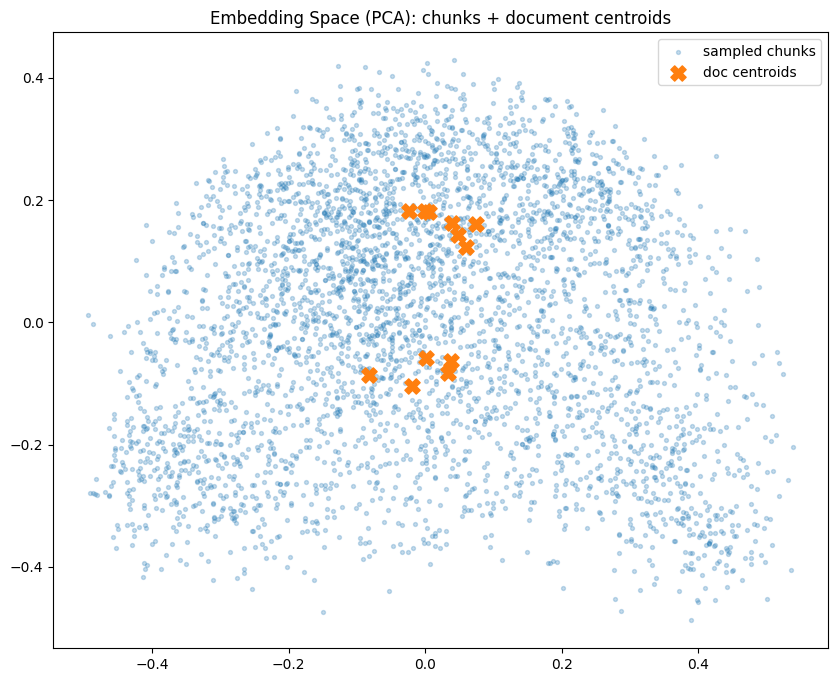

In [25]:
def compute_doc_centroids(X: np.ndarray, corpus: Dict[str,Any]):
    doc_ranges = corpus["doc_ranges"]
    sources = list(doc_ranges.keys())
    centroids = []
    for src in sources:
        a, b = doc_ranges[src]
        a = min(a, X.shape[0])
        b = min(b, X.shape[0])
        if b <= a:
            centroids.append(np.zeros((X.shape[1],), dtype="float32"))
        else:
            centroids.append(X[a:b].mean(axis=0))
    return np.vstack(centroids), sources

def plot_embedding_space(X: np.ndarray, corpus: Dict[str,Any], sample_n: int = FAISS_SAMPLE_FOR_PLOT):
    n = X.shape[0]
    if n == 0:
        print("Nothing to plot.")
        return
    idx = np.random.choice(n, size=min(sample_n, n), replace=False)
    Xs = X[idx]
    C, _sources = compute_doc_centroids(X, corpus)

    pca = PCA(n_components=2, random_state=0)
    Zs = pca.fit_transform(Xs)
    Zc = pca.transform(C)

    plt.figure(figsize=(10, 8))
    plt.scatter(Zs[:,0], Zs[:,1], s=8, alpha=0.25, label="sampled chunks")
    plt.scatter(Zc[:,0], Zc[:,1], s=120, marker="X", label="doc centroids")
    plt.title("Embedding Space (PCA): chunks + document centroids")
    plt.legend()
    plt.show()

plot_embedding_space(X, corpus)


ERROR: Could not find a version that satisfies the requirement widget (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for widget


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


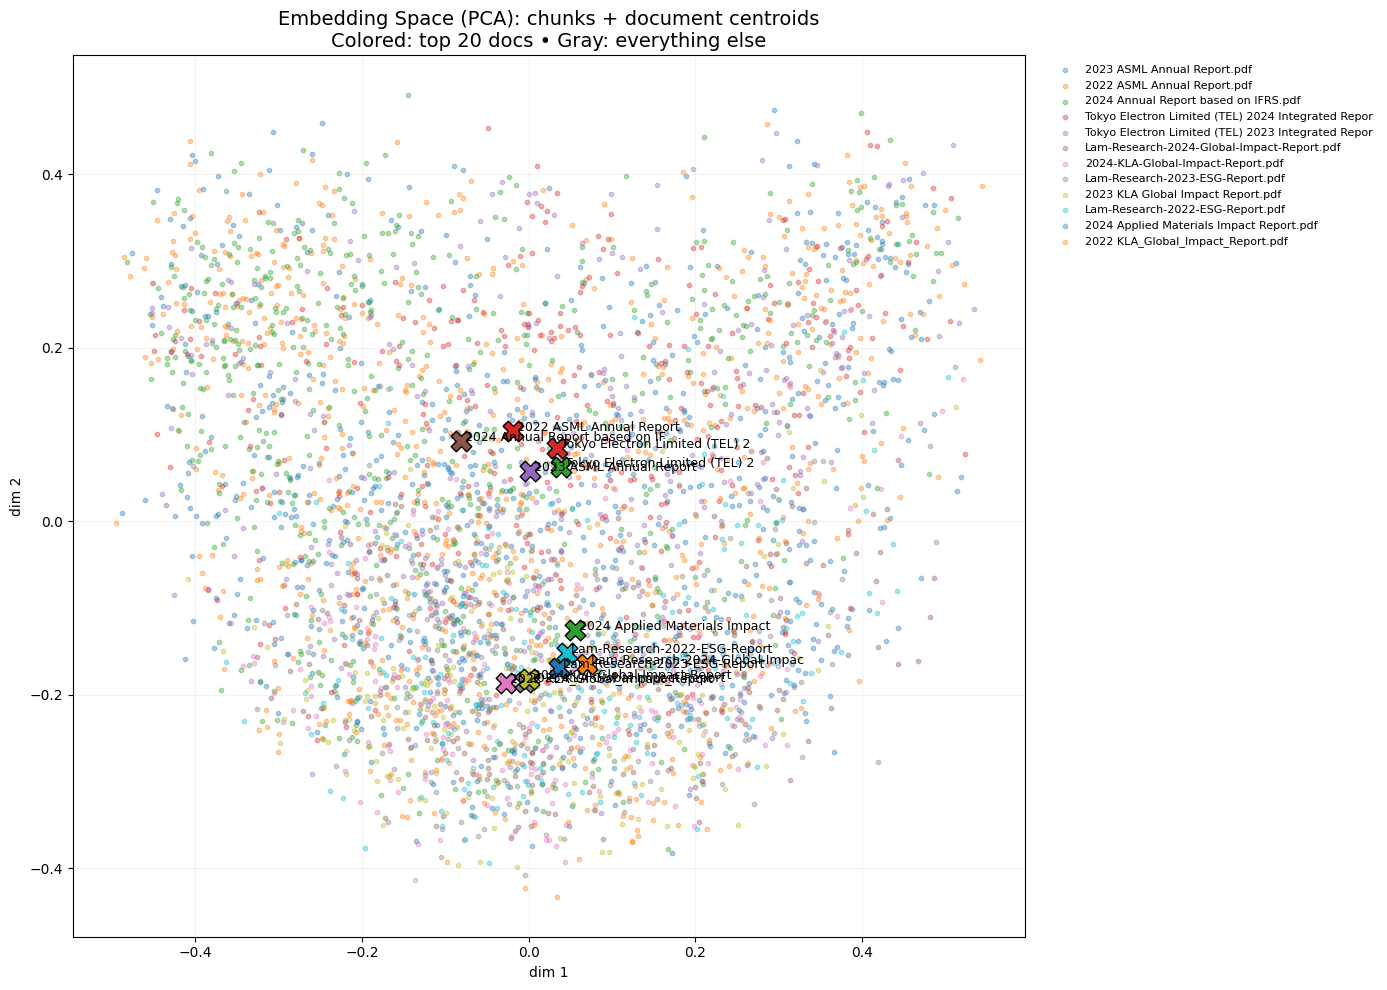

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from collections import Counter
%pip install matplotlib widget

def compute_doc_centroids(X: np.ndarray, corpus):
    doc_ranges = corpus["doc_ranges"]
    sources = list(doc_ranges.keys())
    centroids = []
    for src in sources:
        a, b = doc_ranges[src]
        a = min(a, X.shape[0])
        b = min(b, X.shape[0])
        if b <= a:
            centroids.append(np.zeros((X.shape[1],), dtype="float32"))
        else:
            centroids.append(X[a:b].mean(axis=0))
    return np.vstack(centroids), sources


def plot_embedding_space_matplotlib(
    X: np.ndarray,
    corpus,
    sample_n: int = 4000,
    top_docs: int = 50,              # color these distinctly, rest become gray
    annotate_centroids: int = 15,    # label the biggest docs (by chunk count)
    reduce_method: str = "pca",      # "pca" or "umap"
    random_state: int = 0
):
    n = X.shape[0]
    if n == 0:
        print("Nothing to plot.")
        return

    doc_ranges = corpus["doc_ranges"]

    # --- choose docs to highlight (largest by chunk count) ---
    sizes = {src: max(0, min(b, n) - min(a, n)) for src, (a, b) in doc_ranges.items()}
    top_sources = [s for s, _ in sorted(sizes.items(), key=lambda kv: kv[1], reverse=True)[:top_docs]]

    # --- sample chunks ---
    rng = np.random.default_rng(random_state)
    idx = rng.choice(n, size=min(sample_n, n), replace=False)
    Xs = X[idx]

    # --- reduce to 2D ---
    if reduce_method.lower() == "umap":
        try:
            import umap  # pip install umap-learn
            reducer = umap.UMAP(n_components=2, random_state=random_state)
            Zs = reducer.fit_transform(Xs)
            # Fit centroids in same space: easiest is transform via embedding in same reducer
            C, sources = compute_doc_centroids(X, corpus)
            Zc = reducer.transform(C)
            title = "Embedding Space (UMAP): chunks + document centroids"
        except Exception as e:
            print("UMAP unavailable/failing; falling back to PCA. Error:", e)
            reduce_method = "pca"

    if reduce_method.lower() == "pca":
        pca = PCA(n_components=2, random_state=random_state)
        Zs = pca.fit_transform(Xs)
        C, sources = compute_doc_centroids(X, corpus)
        Zc = pca.transform(C)
        title = "Embedding Space (PCA): chunks + document centroids"

    # --- assign per-point doc labels ---
    metas = corpus["metas"]
    point_src = np.array([metas[i]["source_path"] for i in idx], dtype=object)

    # --- build a stable color map for top docs ---
    tab20 = plt.get_cmap("tab20").colors
    color_map = {}
    for i, src in enumerate(top_sources):
        color_map[src] = tab20[i % len(tab20)]

    # --- plot ---
    plt.figure(figsize=(14, 10))

    # background: "other docs" in gray
    other_mask = ~np.isin(point_src, np.array(top_sources, dtype=object))
    if np.any(other_mask):
        plt.scatter(
            Zs[other_mask, 0], Zs[other_mask, 1],
            s=8, alpha=0.12
        )

    # foreground: top docs colored
    for src in top_sources:
        m = (point_src == src)
        if not np.any(m):
            continue
        plt.scatter(
            Zs[m, 0], Zs[m, 1],
            s=10, alpha=0.35,
            label=Path(src).name[:50]
        )

    # centroids as big X, colored if in top_sources else black
    for j, src in enumerate(sources):
        c = color_map.get(src, (0, 0, 0))
        plt.scatter(
            Zc[j, 0], Zc[j, 1],
            marker="X", s=220,
            edgecolor="black", linewidth=1.0
        )

    # annotate biggest centroids
    biggest = [s for s, _ in sorted(sizes.items(), key=lambda kv: kv[1], reverse=True)[:annotate_centroids]]
    src_to_centroid_idx = {s: i for i, s in enumerate(sources)}
    for s in biggest:
        i = src_to_centroid_idx.get(s, None)
        if i is None:
            continue
        name = Path(s).stem[:30]
        plt.text(Zc[i, 0], Zc[i, 1], " " + name, fontsize=9)

    plt.title(title + f"\nColored: top {top_docs} docs • Gray: everything else", fontsize=14)
    plt.xlabel("dim 1")
    plt.ylabel("dim 2")
    plt.grid(alpha=0.15)

    # legend outside
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
    plt.tight_layout()
    plt.show()


# Run it
plot_embedding_space_matplotlib(X, corpus, sample_n=FAISS_SAMPLE_FOR_PLOT, top_docs=20, annotate_centroids=15, reduce_method="pca")

In [27]:
# %pip install plotly pandas nbformat 
# %pip install -U nbformat ipython ipykernel jupyterlab

import numpy as np
import pandas as pd
import plotly.express as px
from pathlib import Path
from sklearn.decomposition import PCA
import plotly.io as pio
pio.renderers.default = "notebook_connected"  # good for Jupyter + VS Code

def compute_doc_centroids(X: np.ndarray, corpus):
    doc_ranges = corpus["doc_ranges"]
    sources = list(doc_ranges.keys())
    centroids = []
    for src in sources:
        a, b = doc_ranges[src]
        a = min(a, X.shape[0])
        b = min(b, X.shape[0])
        if b <= a:
            centroids.append(np.zeros((X.shape[1],), dtype="float32"))
        else:
            centroids.append(X[a:b].mean(axis=0))
    return np.vstack(centroids), sources


def plot_embedding_space_interactive(
    X: np.ndarray,
    corpus,
    sample_n: int = 4000,
    preview_chars: int = 120,
    random_state: int = 0
):
    n = X.shape[0]
    if n == 0:
        print("Nothing to plot.")
        return

    # --- sample chunks for speed ---
    rng = np.random.default_rng(random_state)
    idx = rng.choice(n, size=min(sample_n, n), replace=False)
    Xs = X[idx]

    # --- doc centroids ---
    C, sources = compute_doc_centroids(X, corpus)

    # --- PCA to 2D ---
    pca = PCA(n_components=2, random_state=random_state)
    Zs = pca.fit_transform(Xs)
    Zc = pca.transform(C)

    # --- build dataframe for chunks ---
    metas = corpus["metas"]
    texts = corpus["texts"]

    chunk_rows = []
    for j, global_i in enumerate(idx):
        m = metas[global_i]
        src = m["source_path"]
        chunk_rows.append({
            "kind": "chunk",
            "x": float(Zs[j, 0]),
            "y": float(Zs[j, 1]),
            "doc": Path(src).name,
            "source_path": src,
            "chunk_index": int(m.get("chunk_index", -1)),
            "preview": (texts[global_i][:preview_chars].replace("\n", " ") if texts[global_i] else "")
        })

    # --- build dataframe for centroids ---
    centroid_rows = []
    for i, src in enumerate(sources):
        centroid_rows.append({
            "kind": "centroid",
            "x": float(Zc[i, 0]),
            "y": float(Zc[i, 1]),
            "doc": Path(src).name,
            "source_path": src,
            "chunk_index": None,
            "preview": "DOCUMENT CENTROID"
        })

    df = pd.DataFrame(chunk_rows + centroid_rows)

    # --- plot ---
    fig = px.scatter(
        df,
        x="x",
        y="y",
        color="doc",
        symbol="kind",
        symbol_map={"chunk": "circle", "centroid": "x"},
        hover_data={
            "doc": True,
            "kind": True,
            "source_path": True,
            "chunk_index": True,
            "preview": True,
            "x": False,
            "y": False
        },
        title="Interactive Embedding Space (PCA) • Hover for details • Click legend to toggle docs"
    )

    # Make centroids visually louder
    fig.update_traces(
        selector=dict(marker_symbol="x"),
        marker=dict(size=18, line=dict(width=2, color="black"))
    )
    fig.update_traces(
        selector=dict(marker_symbol="circle"),
        marker=dict(size=6),
        opacity=0.35
    )

    fig.update_layout(
        height=800,
        legend_title_text="Document (click to hide/show)",
    )
   
    try:
        fig.show()
    except Exception as e:
        print("⚠️ Plotly couldn't render in-notebook:", e)
        out = "embedding_space_interactive.html"
        fig.write_html(out)
        print(f"✅ Saved interactive plot to: {out} (open in browser)")

    return df, fig


# Run it
df_plot, fig = plot_embedding_space_interactive(X, corpus, sample_n=FAISS_SAMPLE_FOR_PLOT)

⚠️ Plotly couldn't render in-notebook: Mime type rendering requires nbformat>=4.2.0 but it is not installed
✅ Saved interactive plot to: embedding_space_interactive.html (open in browser)


## 11) Optional: Claude adversarial Q/A generation (skips if not configured)

Claude credentials are **optional**:
- If `ANTHROPIC_API_KEY` is empty OR `anthropic` isn't installed, this section prints a skip message and does nothing.


In [28]:
def claude_available() -> bool:
    return bool(ANTHROPIC_API_KEY) and (anthropic is not None)

def generate_adversarial_qa_with_claude(sample_texts: List[str], n_pairs: int = 10) -> List[Dict[str,str]]:
    if not claude_available():
        return []

    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    joined = "\n\n---\n\n".join([t[:900] for t in sample_texts])

    prompt = f"""Generate {n_pairs} adversarial QA pairs to test semantic retrieval.

Rules:
- Each QUESTION must be answerable from the excerpts
- Prefer specificity (numbers, dates, names, constraints)
- Answers 1-3 sentences, grounded strictly in the excerpts
- Output as JSON list: [{{"question":"...","answer":"..."}}, ...]

EXCERPTS:
{joined}
"""

    msg = client.messages.create(
        model=CLAUDE_MODEL,
        max_tokens=1600,
        messages=[{"role":"user","content":[{"type":"text","text":prompt}]}],
    )

    text = ""
    for block in msg.content:
        if getattr(block, "type", None) == "text":
            text += block.text

    try:
        qa = json.loads(text)
        return [q for q in qa if "question" in q and "answer" in q]
    except Exception:
        print("Claude output wasn't valid JSON; skipping.")
        return []

def run_retrieval_eval(qa_pairs: List[Dict[str,str]], top_k: int = 5):
    if not qa_pairs:
        print("No QA pairs to evaluate.")
        return
    if IS_MILVUS:
        print("Milvus eval TODO: enable at work.")
        return

    for i, qa in enumerate(qa_pairs, start=1):
        q = qa["question"]
        hits = faiss_search(q, k=top_k)
        print(f"\nQ{i:02d}: {q}")
        if hits:
            score, meta, txt = hits[0]
            print("Top hit:", meta["source_path"], "| score=", score)
            print("Snippet:", txt[:240].replace("\n"," "))
        else:
            print("No hits.")

if claude_available():
    n = min(8, len(corpus["texts"]))
    if n > 0:
        sample_idxs = np.random.choice(len(corpus["texts"]), size=n, replace=False)
        sample_texts = [corpus["texts"][i] for i in sample_idxs]
        qa_pairs = generate_adversarial_qa_with_claude(sample_texts, n_pairs=10)
        print("Generated QA pairs:", len(qa_pairs))
        run_retrieval_eval(qa_pairs, top_k=5)
    else:
        print("No corpus text to sample.")
else:
    print("Claude not configured; skipping adversarial QA generation ✅")


NotFoundError: Error code: 404 - {'type': 'error', 'error': {'type': 'not_found_error', 'message': 'model: claude-3-5-sonnet-latest'}, 'request_id': 'req_011CYfVLP3KcYeVYUuTyxjUH'}